# Overview of the Analysis

The goal of this SPM analysis was to compare time series dynamic stability between overground (OG) and treadmill (TM) walking using center-of-mass (COM) time series and velocity of COM time series in people with Parkinson's disease.

($\it{a}$) Stability at TD: n = 16, OG = 0.0858 +/- 0.0448, TM = 0.0623 +/- 0.0458, Wilcoxon signed-rank, p = 0.1046, significance = ns
($\it{b}$) COM position at TD: n = 16, OG = -0.8274 +/- 0.1698, TM = -0.5437 +/- 0.2593, Paired t-test, p = 0.0000, significance = ***
($\it{c}$) COM velocity at TD: n = 16, OG = 0.3129 +/- 0.0659, TM = 0.2211 +/- 0.0735, Paired t-test, p = 0.0002, significance = ***
($\it{d}$) Stability at LO: n = 16, OG = 0.2285 +/- 0.0421, TM = 0.2233 +/- 0.0391, Paired t-test, p = 0.6795, significance = ns
($\it{e}$) COM position at LO: n = 16, OG = -0.2394 +/- 0.1456, TM = 0.0502 +/- 0.2089, Paired t-test, p = 0.0000, significance = ***
($\it{f}$) COM velocity at LO: n = 16, OG = 0.3116 +/- 0.0648, TM = 0.2302 +/- 0.0771, Paired t-test, p = 0.0007, significance = ***
($\it{g}$) Gait speed: n = 16, OG = 0.7075 +/- 0.1418, TM = 0.5229 +/- 0.1677, Paired t-test, p = 0.0005, significance = ***
($\it{h}$) Step length: n = 16, OG = 0.3864 +/- 0.0612, TM = 0.2971 +/- 0.0

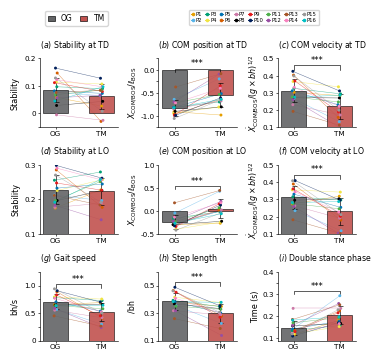

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel, wilcoxon


CSV_FILE = "paired-test.csv"
OUTPUT_FILE = "Figure3.png"
FIG_SIZE = (3.54, 3.2)

TITLE_FONTSIZE = 5.6
TICK_FONTSIZE = 5.2
LABEL_FONTSIZE = 5.8
STAR_FONTSIZE = 6.0
LEGEND_FONTSIZE = 5.5
PARTICIPANT_LEGEND_FONTSIZE = 3.8

BAR_WIDTH = 0.55
BAR_LINEWIDTH = 0.45
ERROR_LINEWIDTH = 0.45
CAPSIZE = 1.8
PAIR_LINEWIDTH = 0.35
SCATTER_SIZE = 4.5
BRACKET_LINEWIDTH = 0.45

DEFAULT_Y_LABELPAD = 1.5

df = pd.read_csv(CSV_FILE)


color_palette = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
    "#E41A1C",
    "#001F5B",
    "#4DAF4A",
    "#984EA3",
    "#A65628",
    "#F781BF",
    "#999999",
    "#00BFC4",
]

participant_labels = [f"P{i + 1}" for i in range(len(df))]

participant_color_map = {
    idx: color_palette[i % len(color_palette)]
    for i, idx in enumerate(df.index)
}

pairs = [
    {
        "og_col": "OG_scomtd",
        "tm_col": "TM_scomtd",
        "title": r"($\it{a}$) Stability at TD",
        "y_label": "Stability",
        "y_ticks": [-0.05, 0, 0.1, 0.2],
        "y_ticklabels": ["", "0", "0.1", "0.2"],
        "y_lim": None,
        "y_labelpad": None,
    },
    {
        "og_col": "OG_xcomtd",
        "tm_col": "TM_xcomtd",
        "title": r"($\it{b}$) COM position at TD",
        "y_label": r"$X_{\mathrm{COM/BOS}}/\ell_{\mathrm{BOS}}$",
        "y_ticks": [-1.25,-1.0,-0.75, -0.5, -0.25, 0.0, 0.25],
        "y_ticklabels": ["", "-1.0", "", "-0.5", "", "0.0", ""],
        "y_lim": (-1.25, 0.25),
        
    },
    {
        "og_col": "OG_vcomtd",
        "tm_col": "TM_vcomtd",
        "title": r"($\it{c}$) COM velocity at TD",
        "y_label": r"$\dot{X}_{\mathrm{COM/BOS}}/(g\times bh)^{1/2}$",
        "y_ticks":  [ 0.1, 0.2, 0.3, 0.4, 0.5],
        "y_ticklabels": [ "0.1", "0.2", "0.3", "0.4", "0.5"],
        "y_lim": (0.1, 0.5),
    },
    {
        "og_col": "OG_scomlo",
        "tm_col": "TM_scomlo",
        "title": r"($\it{d}$) Stability at LO",
        "y_label": "Stability",
        "y_ticks": [0.1, 0.2, 0.3],
        "y_ticklabels":  ["0.1", "0.2", "0.3"],
        "y_lim": (0.1, 0.3),
        "y_labelpad": 3,
    },
    {
        "og_col": "OG_xcomlo",
        "tm_col": "TM_xcomlo",
        "title": r"($\it{e}$) COM position at LO",
        "y_label": r"$X_{\mathrm{COM/BOS}}/\ell_{\mathrm{BOS}}$",
        "y_ticks": [-0.5, 0.0, 0.5, 1.0],
        "y_ticklabels": ["-0.5", "0.0", "0.5", "1.0"],
        "y_lim": (-0.5, 1.0),
        
    },
    {
        "og_col": "OG_vcomlo",
        "tm_col": "TM_vcomlo",
        "title": r"($\it{f}$) COM velocity at LO",
        "y_label": r"$\dot{X}_{\mathrm{COM/BOS}}/(g\times bh)^{1/2}$",
        "y_ticks": [0.1, 0.2, 0.3, 0.4, 0.5],
        "y_ticklabels":  ["0.1", "0.2", "0.3", "0.4", "0.5"],
        "y_lim": (0.1, 0.5),
    },
    {
        "og_col": "OG_speed_N",
        "tm_col": "TM_speed_N",
        "title": r"($\it{g}$) Gait speed",
        "y_label": "bh/s",
        "y_ticks": [0.0,0.25, 0.5, 0.75, 1.0, 1.25],
        "y_ticklabels": ["0", "", "0.5", "", "1.0", ""],
        "y_lim": (0.0, 1.25),
        "y_labelpad": None,
    },
    {
        "og_col": "OG_step_length_N",
        "tm_col": "TM_step_length_N",
        "title": r"($\it{h}$) Step length",
        "y_label": "/bh",
        "y_ticks": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        "y_ticklabels": ["0.1","", "0.3", "", "0.5", ""],
        "y_lim": (0.1, 0.6),
        "y_labelpad": 5,
    },
    {
        "og_col": "OG_doublestancephase",
        "tm_col": "TM_doublestancephase",
        "title": r"($\it{i}$) Double stance phase",
        "y_label": "Time (s)",
        "y_ticks": [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4],
        "y_ticklabels": ["0.1", "", "0.2", "", "0.3", "", "0.4"],
        "y_lim": (0.09, 0.4),
    },
]

bar_colors = ["#636466", "#C1524F"]

wilcoxon_pairs = {
    ("OG_scomtd", "TM_scomtd"),
}


def p_to_star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def plot_metric(ax, metric, rng):
    og_col = metric["og_col"]
    tm_col = metric["tm_col"]
    title = metric["title"]
    y_label = metric.get("y_label")
    y_ticks = metric.get("y_ticks")
    y_ticklabels = metric.get("y_ticklabels")
    y_lim = metric.get("y_lim")
    y_labelpad = metric.get("y_labelpad", DEFAULT_Y_LABELPAD)

    sub = df[[og_col, tm_col]].apply(pd.to_numeric, errors="coerce").dropna()
    og = sub[og_col].to_numpy()
    tm = sub[tm_col].to_numpy()

    row_indices = sub.index.to_numpy()
    point_colors = [participant_color_map[idx] for idx in row_indices]

    means = [np.mean(og), np.mean(tm)]
    sds = [np.std(og, ddof=1), np.std(tm, ddof=1)]

    if (og_col, tm_col) in wilcoxon_pairs:
        _, p_val = wilcoxon(og, tm)
        test_name = "Wilcoxon signed-rank"
    else:
        _, p_val = ttest_rel(og, tm)
        test_name = "Paired t-test"

    sig = p_to_star(p_val)

    ax.bar(
        [0, 1],
        means,
        yerr=sds,
        capsize=CAPSIZE,
        width=BAR_WIDTH,
        color=bar_colors,
        edgecolor="black",
        linewidth=BAR_LINEWIDTH,
        alpha=0.9,
        zorder=2,
        error_kw={
            "elinewidth": ERROR_LINEWIDTH,
            "capthick": ERROR_LINEWIDTH,
        },
    )

    jitter = 0.035
    x_og = rng.uniform(-jitter, jitter, len(og))
    x_tm = 1 + rng.uniform(-jitter, jitter, len(tm))

    for i in range(len(og)):
        ax.plot(
            [x_og[i], x_tm[i]],
            [og[i], tm[i]],
            color=point_colors[i],
            alpha=0.65,
            lw=PAIR_LINEWIDTH,
            zorder=1,
        )

    ax.scatter(x_og, og, c=point_colors, s=SCATTER_SIZE, zorder=3, linewidths=0)
    ax.scatter(x_tm, tm, c=point_colors, s=SCATTER_SIZE, zorder=3, linewidths=0)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["OG", "TM"])
    ax.set_title(title, loc="left", fontsize=TITLE_FONTSIZE, pad=8)
    ax.grid(False)

    if y_label is not None:
        ax.set_ylabel(y_label, fontsize=LABEL_FONTSIZE, labelpad=y_labelpad)

    y_min = min(np.min(og), np.min(tm), means[0] - sds[0], means[1] - sds[1])
    y_max = max(np.max(og), np.max(tm), means[0] + sds[0], means[1] + sds[1])
    y_range = y_max - y_min

    if y_range == 0:
        y_range = max(abs(y_max), 1.0)

    h = y_range * 0.08
    y = y_max + h * 0.4

    if sig:
        ax.plot(
            [0, 0, 1, 1],
            [y, y + h, y + h, y],
            color="black",
            lw=BRACKET_LINEWIDTH,
        )

        ax.text(
            0.5,
            y + h * 1.2,
            sig,
            ha="center",
            va="bottom",
            fontsize=STAR_FONTSIZE,
        )

    if y_lim is None:
        if sig:
            ax.set_ylim(y_min - h, y + h * 2.0)
        else:
            ax.set_ylim(y_min - h, y_max + h)
    else:
        ax.set_ylim(y_lim)

    if y_ticks is not None:
        ax.set_yticks(y_ticks)

    if y_ticklabels is not None:
        ax.set_yticklabels(y_ticklabels)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.45)
    ax.spines["bottom"].set_linewidth(0.45)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=0.45, length=1.5, pad=1.0)
    ax.tick_params(axis="y", length=1.5)

    print(
        f"{title}: n = {len(og)}, "
        f"OG = {means[0]:.4f} +/- {sds[0]:.4f}, "
        f"TM = {means[1]:.4f} +/- {sds[1]:.4f}, "
        f"{test_name}, p = {p_val:.4f}, significance = {sig if sig else 'ns'}"
    )


rng = np.random.default_rng(42)
fig, axes = plt.subplots(3, 3, figsize=FIG_SIZE, constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, pairs):
    plot_metric(ax, metric, rng)

condition_legend_handles = [
    Patch(facecolor=bar_colors[0], edgecolor="black", linewidth=BAR_LINEWIDTH, label="OG"),
    Patch(facecolor=bar_colors[1], edgecolor="black", linewidth=BAR_LINEWIDTH, label="TM"),
]

fig.legend(
    handles=condition_legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.1, 1.085),
    ncol=2,
    frameon=True,
    fontsize=LEGEND_FONTSIZE,
    handlelength=0.9,
    handleheight=0.6,
    columnspacing=1.0,
)

participant_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        color=participant_color_map[idx],
        markerfacecolor=participant_color_map[idx],
        markeredgecolor="none",
        markersize=2.6,
        linewidth=0.7,
        label=f"P{i + 1}",
    )
    for i, idx in enumerate(df.index)
]

fig.legend(
    handles=participant_legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.7, 1.02),
    ncol=8,
    frameon=True,
    fontsize=PARTICIPANT_LEGEND_FONTSIZE,
    handlelength=0.7,
    handletextpad=0.25,
    columnspacing=0.55,
    labelspacing=0.25,
)

fig.savefig(OUTPUT_FILE, dpi=1000, bbox_inches="tight")
plt.show()


====== Stability ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
OG mean LO percent: 25.6950
TM mean LO percent: 35.8931
Stability - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.6512
Number of significant clusters: 1
  Cluster 1: 0% to 100% | p = 0.00378 | Mean Difference (OG-TM) = 0.0804 | Cohen's dz (OG-TM) = 1.1405

====== COM position ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
OG mean LO percent: 25.6950
TM mean LO percent: 35.8931
COM position - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.9792
Number of significant clusters: 2
  Cluster 1: 0% to 43% | p = 0.00284 | Mean Difference (OG-TM) = -0.1689 | Cohen's dz (OG-TM) = -1.6653
  Cluster 2: 72% to 100% | p = 0.01481 | Mean Difference (OG-TM) = 0.1579 | Cohen's dz (OG-TM) = 0.9855

====== COM velocity ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
OG mean LO percent: 25.6

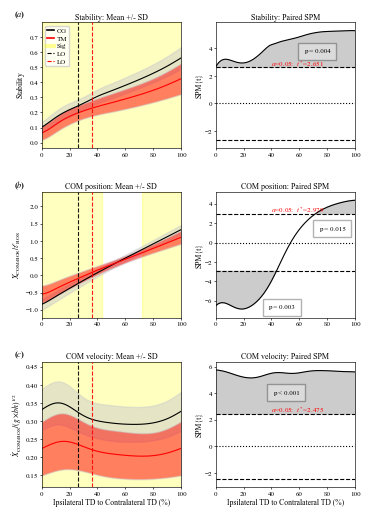

Plot saved as 'Figure4.png'


In [2]:
import numpy as np
import pandas as pd
import spm1d
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# -----------------------
# Figure style
# -----------------------

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",  
})
FIG_SIZE = (3.54, 5)
TITLE_FONTSIZE = 5.8
LABEL_FONTSIZE = 5.5
TICK_FONTSIZE = 5.0
LEGEND_FONTSIZE = 5.0
THRESHOLD_FONTSIZE = 5.0
PVALUE_FONTSIZE = 5.0
SUMMARY_TEXT_FONTSIZE = 5.0
ROW_LABEL_FONTSIZE = 6.0

LINEWIDTH = 0.8
LEGEND_LINEWIDTH = 1.2
LO_LINEWIDTH = 0.8

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 1.5,
    "ytick.major.size": 1.5,
})

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",  
})



tasks = ["stability", "XCOM", "VCOM"]
row_labels = [r"($a$)", r"($b$)", r"($c$)"]

task_display_names = {
    "stability": "Stability",
    "XCOM": "COM position",
    "VCOM": "COM velocity",
}

task_file_map = {
    "stability": ("stability_OG.csv", "stability_TM.csv"),
    "XCOM": ("Xcom_OG.csv", "Xcom_TM.csv"),
    "VCOM": ("Vcom_OG.csv", "Vcom_TM.csv"),
}

ylabel_map = {
    "stability": r"$\mathrm{Stability}$",
    "XCOM": r"$X_{\mathrm{COM/BOS}}/\ell_{\mathrm{BOS}}$",
    "VCOM": r"$\dot{X}_{\mathrm{COM/BOS}}/(g\times bh)^{1/2}$",
}

xlabel_text = "Ipsilateral TD to Contralateral TD (%)"

# -----------------------
# LO line settings
# -----------------------
LO_COLUMN = "mean_lo_percent"
SHOW_LO_LINE = True

manual_p_offsets = {
    ("stability", "unadj"): [(17, -0.5)],
    ("XCOM", "unadj"): [(27, -0.8), (-3, -2.4)],
    ("VCOM", "unadj"): [(0, -1.5)],
}

manual_sig_text_positions = {
    ("stability", "mean"): [None],
    ("XCOM", "mean"): [None, None],
    ("VCOM", "mean"): [None],
}

ALPHA = 0.05
TWO_TAILED = True

def add_lo_lines(ax, og_lo_percent, tm_lo_percent, show_line=SHOW_LO_LINE):
    if not show_line:
        return

    if og_lo_percent is not None:
        ax.axvline(
            og_lo_percent,
            color="black",
            linestyle="--",
            linewidth=LO_LINEWIDTH,
            alpha=0.9,
            zorder=4,
        )

    if tm_lo_percent is not None:
        ax.axvline(
            tm_lo_percent,
            color="red",
            linestyle="--",
            linewidth=LO_LINEWIDTH,
            alpha=0.9,
            zorder=4,
        )

def add_spm_pvalue_boxes(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    offsets = get_manual_offsets(task, "unadj", Fi, two_tailed=two_tailed)

    for idx, ((s, e), offset) in enumerate(zip(bounds, offsets)):
        pval = None
        if pvals is not None and idx < len(pvals):
            pval = pvals[idx]

        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        x = (s + e) / 2 + offset[0]
        y = float(Fi.zstar) + offset[1]

        ax.text(
            x,
            y,
            p_text,
            fontsize=PVALUE_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                linewidth=0.4,
                alpha=0.85,
                boxstyle="square,pad=0.15",
            ),
            zorder=5,
        )

def load_waveform_df(csv_file):
    df = pd.read_csv(csv_file)
    subj_col = "Subject"

    if subj_col not in df.columns:
        raise ValueError(f"{csv_file}: 'Subject' column not found.")

    if LO_COLUMN not in df.columns:
        raise ValueError(f"{csv_file}: '{LO_COLUMN}' column not found.")

    value_cols = [c for c in df.columns if c not in [subj_col, LO_COLUMN]]

    out = df.copy()
    out[subj_col] = pd.to_numeric(out[subj_col], errors="coerce")
    out[value_cols] = out[value_cols].apply(pd.to_numeric, errors="coerce")
    out[LO_COLUMN] = pd.to_numeric(out[LO_COLUMN], errors="coerce")

    if out[subj_col].isna().any():
        bad_rows = out.index[out[subj_col].isna()].tolist()
        raise ValueError(f"{csv_file}: invalid Subject values at rows {bad_rows}")

    if out[value_cols].isna().any().any():
        raise ValueError(f"{csv_file}: missing or non-numeric waveform values found.")

    if out[LO_COLUMN].isna().any():
        bad_rows = out.index[out[LO_COLUMN].isna()].tolist()
        raise ValueError(f"{csv_file}: missing or non-numeric {LO_COLUMN} values at rows {bad_rows}")

    out[subj_col] = out[subj_col].astype(int)
    out = out.set_index(subj_col)

    waveform_df = out[value_cols]
    lo_series = out[LO_COLUMN]

    return waveform_df, lo_series

def prepare_paired_data(og_file, tm_file):
    og_df, og_lo = load_waveform_df(og_file)
    tm_df, tm_lo = load_waveform_df(tm_file)

    common_subjects = np.array(sorted(set(og_df.index).intersection(set(tm_df.index))))

    if len(common_subjects) == 0:
        raise ValueError("No matched subjects across OG and TM files.")

    YA = og_df.loc[common_subjects].to_numpy(dtype=float)
    YB = tm_df.loc[common_subjects].to_numpy(dtype=float)

    og_lo_mean = float(og_lo.loc[common_subjects].mean())
    tm_lo_mean = float(tm_lo.loc[common_subjects].mean())

    return YA, YB, common_subjects, og_lo_mean, tm_lo_mean

def run_paired_spm(og_file, tm_file, alpha=0.05, two_tailed=True):
    YA, YB, common_subjects, og_lo_mean, tm_lo_mean = prepare_paired_data(og_file, tm_file)
    t = spm1d.stats.ttest_paired(YA, YB)
    Fi = t.inference(alpha, two_tailed=two_tailed, interp=True)
    return YA, YB, common_subjects, Fi, og_lo_mean, tm_lo_mean

def get_sig_mask(Fi, two_tailed=True):
    z = np.asarray(Fi.z)
    thresh = float(Fi.zstar)
    return np.abs(z) > thresh if two_tailed else z > thresh

def _cluster_bounds_from_sigmask(sig_mask):
    bounds = []
    start = None

    for i, is_sig in enumerate(sig_mask):
        if is_sig and start is None:
            start = i
        elif not is_sig and start is not None:
            bounds.append((start, i - 1))
            start = None

    if start is not None:
        bounds.append((start, len(sig_mask) - 1))

    return bounds

def _p_value_from_cluster(cluster_obj):
    for attr in ("P", "p", "p_value", "P_value"):
        if hasattr(cluster_obj, attr):
            try:
                return float(getattr(cluster_obj, attr))
            except Exception:
                pass
    return None

def get_cluster_info(Fi, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    clusters = getattr(Fi, "clusters", None)

    if clusters is None or len(clusters) == 0:
        return bounds, [None] * len(bounds)

    pvals = [_p_value_from_cluster(c) for c in clusters]

    if len(pvals) < len(bounds):
        pvals = pvals + [None] * (len(bounds) - len(pvals))

    return bounds, pvals[:len(bounds)]

def highlight_regions(ax, Fi, two_tailed=True, color="yellow", alpha=0.25):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)

    for s, e in bounds:
        ax.axvspan(s, e, color=color, alpha=alpha, zorder=0)

def get_manual_offsets(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    offsets = manual_p_offsets.get((task, panel), [])

    if len(offsets) < n_clusters:
        offsets = list(offsets) + [(0, 0)] * (n_clusters - len(offsets))

    return offsets[:n_clusters]

def get_sig_text_positions(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    positions = manual_sig_text_positions.get((task, panel), [])

    if len(positions) < n_clusters:
        positions = list(positions) + [None] * (n_clusters - len(positions))

    return positions[:n_clusters]

def add_mean_plot_sig_text(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    positions = get_sig_text_positions(task, "mean", Fi, two_tailed=two_tailed)

    for idx, ((s, e), pos) in enumerate(zip(bounds, positions), start=1):
        if pos is None:
            continue

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        ax.text(
            pos[0],
            pos[1],
            p_text,
            fontsize=SUMMARY_TEXT_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", edgecolor="0.6", alpha=0.75, linewidth=0.4),
        )

def print_inference_summary(YA, YB, Fi, task_label, tag, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)

    print(f"{task_label} - {tag}")
    print(f"SPM threshold zstar: {float(Fi.zstar):.4f}")

    if len(bounds) == 0:
        print("No significant region found.")
        return

    print(f"Number of significant clusters: {len(bounds)}")

    for idx, (s, e) in enumerate(bounds, start=1):
        cluster_mask = np.zeros_like(sig_mask, dtype=bool)
        cluster_mask[s:e + 1] = True
        cluster_mask = cluster_mask & sig_mask

        diff_sig = YA[:, cluster_mask] - YB[:, cluster_mask]
        overall_mean_diff = float(np.mean(diff_sig))
        subj_mean_diff = np.mean(diff_sig, axis=1)
        sd_diff = np.std(subj_mean_diff, ddof=1)
        cohen_dz = np.nan if sd_diff == 0 else np.mean(subj_mean_diff) / sd_diff

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "NA" if pval is None else f"{pval:.5f}"

        print(
            f"  Cluster {idx}: {s}% to {e}% | "
            f"p = {p_text} | "
            f"Mean Difference (OG-TM) = {overall_mean_diff:.4f} | "
            f"Cohen's dz (OG-TM) = {cohen_dz:.4f}"
        )

# -----------------------
# Main figure
# -----------------------
fig, axs = plt.subplots(len(tasks), 2, figsize=FIG_SIZE, constrained_layout=False)

fig.subplots_adjust(
    left=0.11,
    right=0.995,
    bottom=0.05,
    top=0.98,
    hspace=0.35,
    wspace=0.25,
)

if len(tasks) == 1:
    axs = np.array([axs])

for i, task in enumerate(tasks):
    display_name = task_display_names[task]
    og_file, tm_file = task_file_map[task]

    YA, YB, subjects, ti_unadj, og_lo_mean, tm_lo_mean = run_paired_spm(
        og_file,
        tm_file,
        alpha=ALPHA,
        two_tailed=TWO_TAILED,
    )

    print(f"\n====== {display_name} ======")
    print(f"Matched subjects (n={len(subjects)}): {subjects.tolist()}")
    print(f"OG mean LO percent: {og_lo_mean:.4f}")
    print(f"TM mean LO percent: {tm_lo_mean:.4f}")

    print_inference_summary(
        YA,
        YB,
        ti_unadj,
        display_name,
        "Paired SPM, direction = OG-TM",
        two_tailed=TWO_TAILED,
    )

    ax_mean = axs[i, 0]

    ax_mean.text(
        -0.2,
        1.1,
        row_labels[i],
        transform=ax_mean.transAxes,
        fontsize=ROW_LABEL_FONTSIZE,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )

    highlight_regions(ax_mean, ti_unadj, two_tailed=TWO_TAILED, color="yellow", alpha=0.25)

    spm1d.plot.plot_mean_sd(YA, ax=ax_mean)
    spm1d.plot.plot_mean_sd(YB, ax=ax_mean, linecolor="r", facecolor="r")
    add_mean_plot_sig_text(ax_mean, task, ti_unadj, two_tailed=TWO_TAILED)
    add_lo_lines(ax_mean, og_lo_mean, tm_lo_mean)

    ax_mean.set_title(f"{display_name}: Mean +/- SD", fontsize=TITLE_FONTSIZE, pad=2)
    ax_mean.set_ylabel(ylabel_map[task], fontsize=LABEL_FONTSIZE, labelpad=1.5)
    ax_mean.grid(False)

    if i == len(tasks) - 1:
        ax_mean.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_mean.set_xlabel("")

    if i == 0:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color="black", lw=LEGEND_LINEWIDTH, label="OG"),
                Line2D([0], [0], color="red", lw=LEGEND_LINEWIDTH, label="TM"),
                Line2D([0], [0], color="yellow", lw=3, alpha=0.4, label="Sig"),
                Line2D([0], [0], color="black", lw=LO_LINEWIDTH, linestyle="--", label="LO"),
                Line2D([0], [0], color="red", lw=LO_LINEWIDTH, linestyle="--", label="LO"),
            ],
            loc="upper left",
            fontsize=LEGEND_FONTSIZE,
            frameon=True,
            borderpad=0.25,
            labelspacing=0.25,
            handlelength=1.0,
            handletextpad=0.4,
        )

    ax_unadj = axs[i, 1]
    ti_unadj.plot(ax=ax_unadj)
    ti_unadj.plot_threshold_label(ax=ax_unadj, fontsize=THRESHOLD_FONTSIZE)

    ax_unadj.set_ylabel("SPM{t}", fontsize=LABEL_FONTSIZE, labelpad=1.5)

    bounds, _ = get_cluster_info(ti_unadj, two_tailed=TWO_TAILED)

    if len(bounds) > 0:
        try:
            ti_unadj.plot_p_values(
                size=PVALUE_FONTSIZE,
                offsets=get_manual_offsets(task, "unadj", ti_unadj, two_tailed=TWO_TAILED),
                ax=ax_unadj,
            )
        except Exception as e:
            print(f"{display_name} - p-value plotting failed: {e}")

    ax_unadj.set_title(f"{display_name}: Paired SPM", fontsize=TITLE_FONTSIZE, pad=2)
    ax_unadj.grid(False)

    if i == len(tasks) - 1:
        ax_unadj.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_unadj.set_xlabel("")

    for ax in (ax_mean, ax_unadj):
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=0.45, length=1.5, pad=1.0)

        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(0.45)

        for line in ax.lines:
            line.set_linewidth(LINEWIDTH)

plt.savefig("Figure4.png", dpi=1000, bbox_inches="tight")
plt.show()

print("Plot saved as 'Figure4.png'")


====== Stability ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
Stability - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.4878
Number of significant clusters: 1
  Cluster 1: 0% to 18% | p = 0.04865 | Mean Difference (OG-TM) = 0.0358 | Cohen's dz (OG-TM) = 0.6624

====== COM position ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
COM position - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.5142
Number of significant clusters: 1
  Cluster 1: 0% to 100% | p = 0.00000 | Mean Difference (OG-TM) = -0.2989 | Cohen's dz (OG-TM) = -2.1556

====== COM velocity ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
COM velocity - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.2545
Number of significant clusters: 1
  Cluster 1: 0% to 100% | p = 0.00009 | Mean Difference (OG-TM) = 0.1048 | Cohen's dz (OG-TM) = 1.3957


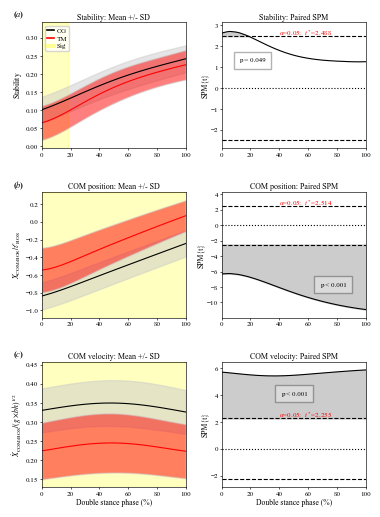

Plot saved as 'Figure5.png'


In [3]:
import numpy as np
import pandas as pd
import spm1d
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# -----------------------
# Figure style
# -----------------------

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",  # 수식 글꼴도 Times 계열과 비슷하게
})
FIG_SIZE = (3.54, 5)
ROW_LABEL_FONTSIZE = 6.0
TITLE_FONTSIZE = 5.8
LABEL_FONTSIZE = 5.5
TICK_FONTSIZE = 5.0
LEGEND_FONTSIZE = 5.0
THRESHOLD_FONTSIZE = 5.0
PVALUE_FONTSIZE = 5.0
SUMMARY_TEXT_FONTSIZE = 5.0

LINEWIDTH = 0.8
LEGEND_LINEWIDTH = 1.2

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 1.5,
    "ytick.major.size": 1.5,
})

tasks = ["stability", "XCOM", "VCOM"]

task_display_names = {
    "stability": "Stability",
    "XCOM": "COM position",
    "VCOM": "COM velocity",
}

task_file_map = {
    "stability": ("stability_OG_double.csv", "stability_TM_double.csv"),
    "XCOM": ("Xcom_OG_double.csv", "Xcom_TM_double.csv"),
    "VCOM": ("Vcom_OG_double.csv", "Vcom_TM_double.csv"),
}

ylabel_map = {
    "stability": r"$\mathrm{Stability}$",
    "XCOM": r"$X_{\mathrm{COM/BOS}}/\ell_{\mathrm{BOS}}$",
    "VCOM": r"$\dot{X}_{\mathrm{COM/BOS}}/(g\times bh)^{1/2}$",
}

xlabel_text = "Double stance phase (%)"

manual_p_offsets = {
    ("stability", "unadj"): [(12, -1.3)],
    ("XCOM", "unadj"): [(22, 0.9)],
    ("VCOM", "unadj"): [(0, -1.5)],
}

manual_sig_text_positions = {
    ("stability", "mean"): [None],
    ("XCOM", "mean"): [None, None],
    ("VCOM", "mean"): [None],
}

ALPHA = 0.05
TWO_TAILED = True

def add_spm_pvalue_boxes(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    offsets = get_manual_offsets(task, "unadj", Fi, two_tailed=two_tailed)

    for idx, ((s, e), offset) in enumerate(zip(bounds, offsets)):
        pval = None
        if pvals is not None and idx < len(pvals):
            pval = pvals[idx]

        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        x = (s + e) / 2 + offset[0]
        y = float(Fi.zstar) + offset[1]

        ax.text(
            x,
            y,
            p_text,
            fontsize=PVALUE_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                linewidth=0.4,
                alpha=0.85,
                boxstyle="square,pad=0.15",
            ),
            zorder=5,
        )
        
def load_waveform_df(csv_file):
    df = pd.read_csv(csv_file)
    subj_col = "Subject"

    if subj_col not in df.columns:
        raise ValueError(f"{csv_file}: 'Subject' column not found.")

    value_cols = [c for c in df.columns if c != subj_col]

    out = df.copy()
    out[subj_col] = pd.to_numeric(out[subj_col], errors="coerce")
    out[value_cols] = out[value_cols].apply(pd.to_numeric, errors="coerce")

    out[subj_col] = out[subj_col].astype(int)
    return out.set_index(subj_col)[value_cols]


def prepare_paired_data(og_file, tm_file):
    og_df = load_waveform_df(og_file)
    tm_df = load_waveform_df(tm_file)

    common_subjects = np.array(sorted(set(og_df.index).intersection(set(tm_df.index))))

    YA = og_df.loc[common_subjects].to_numpy(dtype=float)
    YB = tm_df.loc[common_subjects].to_numpy(dtype=float)

    return YA, YB, common_subjects


def run_paired_spm(og_file, tm_file, alpha=0.05, two_tailed=True):
    YA, YB, common_subjects = prepare_paired_data(og_file, tm_file)
    t = spm1d.stats.ttest_paired(YA, YB)
    Fi = t.inference(alpha, two_tailed=two_tailed, interp=True)
    return YA, YB, common_subjects, Fi


def get_sig_mask(Fi, two_tailed=True):
    z = np.asarray(Fi.z)
    thresh = float(Fi.zstar)
    return np.abs(z) > thresh if two_tailed else z > thresh


def _cluster_bounds_from_sigmask(sig_mask):
    bounds = []
    start = None

    for i, is_sig in enumerate(sig_mask):
        if is_sig and start is None:
            start = i
        elif not is_sig and start is not None:
            bounds.append((start, i - 1))
            start = None

    if start is not None:
        bounds.append((start, len(sig_mask) - 1))

    return bounds


def _p_value_from_cluster(cluster_obj):
    for attr in ("P", "p", "p_value", "P_value"):
        if hasattr(cluster_obj, attr):
            try:
                return float(getattr(cluster_obj, attr))
            except Exception:
                pass
    return None


def get_cluster_info(Fi, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    clusters = getattr(Fi, "clusters", None)

    if clusters is None or len(clusters) == 0:
        return bounds, [None] * len(bounds)

    pvals = [_p_value_from_cluster(c) for c in clusters]

    if len(pvals) < len(bounds):
        pvals = pvals + [None] * (len(bounds) - len(pvals))

    return bounds, pvals[:len(bounds)]


def highlight_regions(ax, Fi, two_tailed=True, color="yellow", alpha=0.25):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)

    for s, e in bounds:
        ax.axvspan(s, e, color=color, alpha=alpha, zorder=0)


def get_manual_offsets(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    offsets = manual_p_offsets.get((task, panel), [])

    if len(offsets) < n_clusters:
        offsets = list(offsets) + [(0, 0)] * (n_clusters - len(offsets))

    return offsets[:n_clusters]


def get_sig_text_positions(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    positions = manual_sig_text_positions.get((task, panel), [])

    if len(positions) < n_clusters:
        positions = list(positions) + [None] * (n_clusters - len(positions))

    return positions[:n_clusters]


def add_mean_plot_sig_text(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    positions = get_sig_text_positions(task, "mean", Fi, two_tailed=two_tailed)

    for idx, ((s, e), pos) in enumerate(zip(bounds, positions), start=1):
        if pos is None:
            continue

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        ax.text(
            pos[0],
            pos[1],
            p_text,
            fontsize=SUMMARY_TEXT_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", edgecolor="0.6", alpha=0.75, linewidth=0.4),
        )


def print_inference_summary(YA, YB, Fi, task_label, tag, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)

    print(f"{task_label} - {tag}")
    print(f"SPM threshold zstar: {float(Fi.zstar):.4f}")

    if len(bounds) == 0:
        print("No significant region found.")
        return

    print(f"Number of significant clusters: {len(bounds)}")

    for idx, (s, e) in enumerate(bounds, start=1):
        cluster_mask = np.zeros_like(sig_mask, dtype=bool)
        cluster_mask[s:e + 1] = True
        cluster_mask = cluster_mask & sig_mask

        diff_sig = YA[:, cluster_mask] - YB[:, cluster_mask]
        overall_mean_diff = float(np.mean(diff_sig))
        subj_mean_diff = np.mean(diff_sig, axis=1)
        sd_diff = np.std(subj_mean_diff, ddof=1)
        cohen_dz = np.nan if sd_diff == 0 else np.mean(subj_mean_diff) / sd_diff

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "NA" if pval is None else f"{pval:.5f}"

        print(
            f"  Cluster {idx}: {s}% to {e}% | "
            f"p = {p_text} | "
            f"Mean Difference (OG-TM) = {overall_mean_diff:.4f} | "
            f"Cohen's dz (OG-TM) = {cohen_dz:.4f}"
        )


# -----------------------
# Main figure
# -----------------------
fig, axs = plt.subplots(len(tasks), 2, figsize=FIG_SIZE, constrained_layout=False)


fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.05,
    top=0.98,
    hspace=0.35,
    wspace=0.25,
)

if len(tasks) == 1:
    axs = np.array([axs])

for i, task in enumerate(tasks):
    display_name = task_display_names[task]
    og_file, tm_file = task_file_map[task]

    YA, YB, subjects, ti_unadj = run_paired_spm(
        og_file,
        tm_file,
        alpha=ALPHA,
        two_tailed=TWO_TAILED,
    )

    print(f"\n====== {display_name} ======")
    print(f"Matched subjects (n={len(subjects)}): {subjects.tolist()}")

    print_inference_summary(
        YA,
        YB,
        ti_unadj,
        display_name,
        "Paired SPM, direction = OG-TM",
        two_tailed=TWO_TAILED,
    )

    ax_mean = axs[i, 0]
  

    ax_mean.text(
        -0.2,
        1.1,
        row_labels[i],
        transform=ax_mean.transAxes,
        fontsize=ROW_LABEL_FONTSIZE,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )
    highlight_regions(ax_mean, ti_unadj, two_tailed=TWO_TAILED, color="yellow", alpha=0.25)

    spm1d.plot.plot_mean_sd(YA, ax=ax_mean)
    spm1d.plot.plot_mean_sd(YB, ax=ax_mean, linecolor="r", facecolor="r")
    add_mean_plot_sig_text(ax_mean, task, ti_unadj, two_tailed=TWO_TAILED)

    ax_mean.set_title(f"{display_name}: Mean +/- SD", fontsize=TITLE_FONTSIZE, pad=2)
    ax_mean.set_ylabel(ylabel_map[task], fontsize=LABEL_FONTSIZE, labelpad=1.5)
    ax_mean.grid(False)

    if i == len(tasks) - 1:
        ax_mean.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_mean.set_xlabel("")

    if i == 0:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color="black", lw=LEGEND_LINEWIDTH, label="OG"),
                Line2D([0], [0], color="red", lw=LEGEND_LINEWIDTH, label="TM"),
                Line2D([0], [0], color="yellow", lw=3, alpha=0.4, label="Sig"),
            ],
            loc="upper left",
            fontsize=LEGEND_FONTSIZE,
            frameon=True,
            borderpad=0.25,
            labelspacing=0.25,
            handlelength=1.0,
            handletextpad=0.4,
        )

    ax_unadj = axs[i, 1]
    ti_unadj.plot(ax=ax_unadj)
    ti_unadj.plot_threshold_label(ax=ax_unadj, fontsize=THRESHOLD_FONTSIZE)

    ax_unadj.set_ylabel("SPM{t}", fontsize=LABEL_FONTSIZE, labelpad=1.5)

    bounds, _ = get_cluster_info(ti_unadj, two_tailed=TWO_TAILED)

    if len(bounds) > 0:
        try:
            ti_unadj.plot_p_values(
                size=PVALUE_FONTSIZE,
                offsets=get_manual_offsets(task, "unadj", ti_unadj, two_tailed=TWO_TAILED),
                ax=ax_unadj,
            )
        except Exception as e:
            print(f"{display_name} - p-value plotting failed: {e}")

    ax_unadj.set_title(f"{display_name}: Paired SPM", fontsize=TITLE_FONTSIZE, pad=2)
    ax_unadj.grid(False)

    if i == len(tasks) - 1:
        ax_unadj.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_unadj.set_xlabel("")

    for ax in (ax_mean, ax_unadj):
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=0.45, length=1.5, pad=1.0)

        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(0.45)

        for line in ax.lines:
            line.set_linewidth(LINEWIDTH)

plt.savefig("Figure5.png", dpi=1000, bbox_inches="tight")
plt.show()

print("Plot saved as 'Figure5.png'")


====== Stability ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
Stability - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.5085
Number of significant clusters: 1
  Cluster 1: 14% to 100% | p = 0.02455 | Mean Difference (OG-TM) = 0.0878 | Cohen's dz (OG-TM) = 1.1315

====== COM position ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
COM position - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.8885
Number of significant clusters: 2
  Cluster 1: 0% to 44% | p = 0.00744 | Mean Difference (OG-TM) = -0.1853 | Cohen's dz (OG-TM) = -2.4019
  Cluster 2: 76% to 100% | p = 0.02816 | Mean Difference (OG-TM) = 0.1628 | Cohen's dz (OG-TM) = 0.9527

====== COM velocity ======
Matched subjects (n=16): [4, 6, 8, 10, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 31, 32]
COM velocity - Paired SPM, direction = OG-TM
SPM threshold zstar: 2.3696
Number of significant clusters: 1
  Cluster 1: 0% to 100% | p 

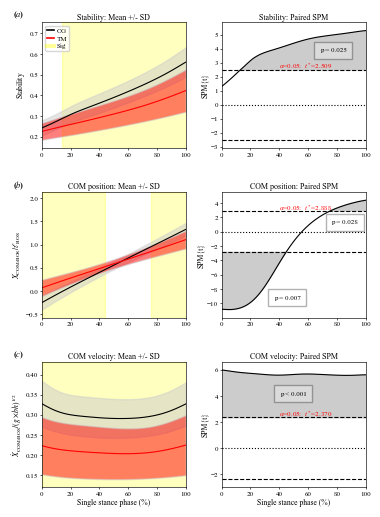

Plot saved as 'Figure6.png'


In [4]:
import numpy as np
import pandas as pd
import spm1d
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D




# -----------------------
# Figure style
# -----------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",  
})
FIG_SIZE = (3.54, 5)
ROW_LABEL_FONTSIZE = 6.0
TITLE_FONTSIZE = 5.8
LABEL_FONTSIZE = 5.5
TICK_FONTSIZE = 5.0
LEGEND_FONTSIZE = 5.0
THRESHOLD_FONTSIZE = 5.0
PVALUE_FONTSIZE = 5.0
SUMMARY_TEXT_FONTSIZE = 5.0

LINEWIDTH = 0.8
LEGEND_LINEWIDTH = 1.2
task_display_names = {
    "stability": "Stability",
    "XCOM": "COM position",
    "VCOM": "COM velocity",
}

row_labels = [r"($a$)", r"($b$)", r"($c$)"]

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
    "axes.linewidth": 0.45,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 1.5,
    "ytick.major.size": 1.5,
})

tasks = ["stability", "XCOM", "VCOM"]

task_display_names = {
    "stability": "Stability",
    "XCOM": "COM position",
    "VCOM": "COM velocity",
}
task_file_map = {
    "stability": ("stability_OG_single.csv", "stability_TM_single.csv"),
    "XCOM": ("Xcom_OG_single.csv", "Xcom_TM_single.csv"),
    "VCOM": ("Vcom_OG_single.csv", "Vcom_TM_single.csv"),
}

ylabel_map = {
    "stability": r"$\mathrm{Stability}$",
    "XCOM": r"$X_{\mathrm{COM/BOS}}/\ell_{\mathrm{BOS}}$",
    "VCOM": r"$\dot{X}_{\mathrm{COM/BOS}}/(g\times bh)^{1/2}$",
}

xlabel_text = "Single stance phase (%)"
manual_p_offsets = {
    ("stability", "unadj"): [(17, -0.5)],
    ("XCOM", "unadj"): [(27, -0.8), (-3, -2.4)],
    ("VCOM", "unadj"): [(0, -1.5)],
}

manual_sig_text_positions = {
    ("stability", "mean"): [None],
    ("XCOM", "mean"): [None, None],
    ("VCOM", "mean"): [None],
}

ALPHA = 0.05
TWO_TAILED = True

def add_spm_pvalue_boxes(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    offsets = get_manual_offsets(task, "unadj", Fi, two_tailed=two_tailed)

    for idx, ((s, e), offset) in enumerate(zip(bounds, offsets)):
        pval = None
        if pvals is not None and idx < len(pvals):
            pval = pvals[idx]

        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        x = (s + e) / 2 + offset[0]
        y = float(Fi.zstar) + offset[1]

        ax.text(
            x,
            y,
            p_text,
            fontsize=PVALUE_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                linewidth=0.4,
                alpha=0.85,
                boxstyle="square,pad=0.15",
            ),
            zorder=5,
        )
        
def load_waveform_df(csv_file):
    df = pd.read_csv(csv_file)
    subj_col = "Subject"

    if subj_col not in df.columns:
        raise ValueError(f"{csv_file}: 'Subject' column not found.")

    value_cols = [c for c in df.columns if c != subj_col]

    out = df.copy()
    out[subj_col] = pd.to_numeric(out[subj_col], errors="coerce")
    out[value_cols] = out[value_cols].apply(pd.to_numeric, errors="coerce")

    out[subj_col] = out[subj_col].astype(int)
    return out.set_index(subj_col)[value_cols]


def prepare_paired_data(og_file, tm_file):
    og_df = load_waveform_df(og_file)
    tm_df = load_waveform_df(tm_file)

    common_subjects = np.array(sorted(set(og_df.index).intersection(set(tm_df.index))))

    YA = og_df.loc[common_subjects].to_numpy(dtype=float)
    YB = tm_df.loc[common_subjects].to_numpy(dtype=float)

    return YA, YB, common_subjects


def run_paired_spm(og_file, tm_file, alpha=0.05, two_tailed=True):
    YA, YB, common_subjects = prepare_paired_data(og_file, tm_file)
    t = spm1d.stats.ttest_paired(YA, YB)
    Fi = t.inference(alpha, two_tailed=two_tailed, interp=True)
    return YA, YB, common_subjects, Fi


def get_sig_mask(Fi, two_tailed=True):
    z = np.asarray(Fi.z)
    thresh = float(Fi.zstar)
    return np.abs(z) > thresh if two_tailed else z > thresh


def _cluster_bounds_from_sigmask(sig_mask):
    bounds = []
    start = None

    for i, is_sig in enumerate(sig_mask):
        if is_sig and start is None:
            start = i
        elif not is_sig and start is not None:
            bounds.append((start, i - 1))
            start = None

    if start is not None:
        bounds.append((start, len(sig_mask) - 1))

    return bounds


def _p_value_from_cluster(cluster_obj):
    for attr in ("P", "p", "p_value", "P_value"):
        if hasattr(cluster_obj, attr):
            try:
                return float(getattr(cluster_obj, attr))
            except Exception:
                pass
    return None


def get_cluster_info(Fi, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    clusters = getattr(Fi, "clusters", None)

    if clusters is None or len(clusters) == 0:
        return bounds, [None] * len(bounds)

    pvals = [_p_value_from_cluster(c) for c in clusters]

    if len(pvals) < len(bounds):
        pvals = pvals + [None] * (len(bounds) - len(pvals))

    return bounds, pvals[:len(bounds)]


def highlight_regions(ax, Fi, two_tailed=True, color="yellow", alpha=0.25):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds = _cluster_bounds_from_sigmask(sig_mask)

    for s, e in bounds:
        ax.axvspan(s, e, color=color, alpha=alpha, zorder=0)


def get_manual_offsets(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    offsets = manual_p_offsets.get((task, panel), [])

    if len(offsets) < n_clusters:
        offsets = list(offsets) + [(0, 0)] * (n_clusters - len(offsets))

    return offsets[:n_clusters]


def get_sig_text_positions(task, panel, Fi, two_tailed=True):
    bounds, _ = get_cluster_info(Fi, two_tailed=two_tailed)
    n_clusters = len(bounds)
    positions = manual_sig_text_positions.get((task, panel), [])

    if len(positions) < n_clusters:
        positions = list(positions) + [None] * (n_clusters - len(positions))

    return positions[:n_clusters]


def add_mean_plot_sig_text(ax, task, Fi, two_tailed=True):
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)
    positions = get_sig_text_positions(task, "mean", Fi, two_tailed=two_tailed)

    for idx, ((s, e), pos) in enumerate(zip(bounds, positions), start=1):
        if pos is None:
            continue

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "p = NA" if pval is None else f"p = {pval:.3f}"

        ax.text(
            pos[0],
            pos[1],
            p_text,
            fontsize=SUMMARY_TEXT_FONTSIZE,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", edgecolor="0.6", alpha=0.75, linewidth=0.4),
        )


def print_inference_summary(YA, YB, Fi, task_label, tag, two_tailed=True):
    sig_mask = get_sig_mask(Fi, two_tailed=two_tailed)
    bounds, pvals = get_cluster_info(Fi, two_tailed=two_tailed)

    print(f"{task_label} - {tag}")
    print(f"SPM threshold zstar: {float(Fi.zstar):.4f}")

    if len(bounds) == 0:
        print("No significant region found.")
        return

    print(f"Number of significant clusters: {len(bounds)}")

    for idx, (s, e) in enumerate(bounds, start=1):
        cluster_mask = np.zeros_like(sig_mask, dtype=bool)
        cluster_mask[s:e + 1] = True
        cluster_mask = cluster_mask & sig_mask

        diff_sig = YA[:, cluster_mask] - YB[:, cluster_mask]
        overall_mean_diff = float(np.mean(diff_sig))
        subj_mean_diff = np.mean(diff_sig, axis=1)
        sd_diff = np.std(subj_mean_diff, ddof=1)
        cohen_dz = np.nan if sd_diff == 0 else np.mean(subj_mean_diff) / sd_diff

        pval = pvals[idx - 1] if pvals is not None and idx - 1 < len(pvals) else None
        p_text = "NA" if pval is None else f"{pval:.5f}"

        print(
            f"  Cluster {idx}: {s}% to {e}% | "
            f"p = {p_text} | "
            f"Mean Difference (OG-TM) = {overall_mean_diff:.4f} | "
            f"Cohen's dz (OG-TM) = {cohen_dz:.4f}"
        )


# -----------------------
# Main figure
# -----------------------
fig, axs = plt.subplots(len(tasks), 2, figsize=FIG_SIZE, constrained_layout=False)


fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.05,
    top=0.98,
    hspace=0.35,
    wspace=0.25,
)

if len(tasks) == 1:
    axs = np.array([axs])

for i, task in enumerate(tasks):
    display_name = task_display_names[task]
    og_file, tm_file = task_file_map[task]

    YA, YB, subjects, ti_unadj = run_paired_spm(
        og_file,
        tm_file,
        alpha=ALPHA,
        two_tailed=TWO_TAILED,
    )

    print(f"\n====== {display_name} ======")
    print(f"Matched subjects (n={len(subjects)}): {subjects.tolist()}")

    print_inference_summary(
        YA,
        YB,
        ti_unadj,
        display_name,
        "Paired SPM, direction = OG-TM",
        two_tailed=TWO_TAILED,
    )

    ax_mean = axs[i, 0]
    ax_mean.text(
    -0.2,
    1.1,
    row_labels[i],
    transform=ax_mean.transAxes,
    fontsize=ROW_LABEL_FONTSIZE,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False,
    )
    highlight_regions(ax_mean, ti_unadj, two_tailed=TWO_TAILED, color="yellow", alpha=0.25)

    spm1d.plot.plot_mean_sd(YA, ax=ax_mean)
    spm1d.plot.plot_mean_sd(YB, ax=ax_mean, linecolor="r", facecolor="r")
    add_mean_plot_sig_text(ax_mean, task, ti_unadj, two_tailed=TWO_TAILED)

    ax_mean.set_title(f"{display_name}: Mean +/- SD", fontsize=TITLE_FONTSIZE, pad=2)
    ax_mean.set_ylabel(ylabel_map[task], fontsize=LABEL_FONTSIZE, labelpad=1.5)
    ax_mean.grid(False)

    if i == len(tasks) - 1:
        ax_mean.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_mean.set_xlabel("")

    if i == 0:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color="black", lw=LEGEND_LINEWIDTH, label="OG"),
                Line2D([0], [0], color="red", lw=LEGEND_LINEWIDTH, label="TM"),
                Line2D([0], [0], color="yellow", lw=3, alpha=0.4, label="Sig"),
            ],
            loc="upper left",
            fontsize=LEGEND_FONTSIZE,
            frameon=True,
            borderpad=0.25,
            labelspacing=0.25,
            handlelength=1.0,
            handletextpad=0.4,
        )

    ax_unadj = axs[i, 1]
    ti_unadj.plot(ax=ax_unadj)
    ti_unadj.plot_threshold_label(ax=ax_unadj, fontsize=THRESHOLD_FONTSIZE)

    ax_unadj.set_ylabel("SPM{t}", fontsize=LABEL_FONTSIZE, labelpad=1.5)

    bounds, _ = get_cluster_info(ti_unadj, two_tailed=TWO_TAILED)

    if len(bounds) > 0:
        try:
            ti_unadj.plot_p_values(
                size=PVALUE_FONTSIZE,
                offsets=get_manual_offsets(task, "unadj", ti_unadj, two_tailed=TWO_TAILED),
                ax=ax_unadj,
            )
        except Exception as e:
            print(f"{display_name} - p-value plotting failed: {e}")

    ax_unadj.set_title(f"{display_name}: Paired SPM", fontsize=TITLE_FONTSIZE, pad=2)
    ax_unadj.grid(False)

    if i == len(tasks) - 1:
        ax_unadj.set_xlabel(xlabel_text, fontsize=LABEL_FONTSIZE, labelpad=1.5)
    else:
        ax_unadj.set_xlabel("")

    for ax in (ax_mean, ax_unadj):
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=0.45, length=1.5, pad=1.0)

        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(0.45)

        for line in ax.lines:
            line.set_linewidth(LINEWIDTH)

plt.savefig("Figure6.png", dpi=1000, bbox_inches="tight")
plt.show()

print("Plot saved as 'Figure6.png'")